In [1]:
import os
import numpy as np
import torch
import h5py as h5

import matplotlib.pyplot as plt
from plotting import imshow_sphere, plot_data, plot_sphere

from torch_harmonics.examples import SphericalSegmentationDataset, SphericalSegmendationDatasetDownloader

In [3]:

data_dir = os.path.join("../examples/data", "2D3DS")
os.makedirs(data_dir, exist_ok=True)

# 2D3DS download & dataset initialization
downloader = SphericalSegmendationDatasetDownloader(base_url="https://cvg-data.inf.ethz.ch/2d3ds/no_xyz/", local_dir=str(data_dir))
dataset_file = downloader.prepare_dataset([("area_3_no_xyz.tar", "area_3"), ("area_5a_no_xyz.tar", "area_5a")])

preparing dataset: 100%|██████████| 85/85 [00:33<00:00,  2.55it/s]


<KeysViewHDF5 ['class_labels', 'inputs', 'targets']>


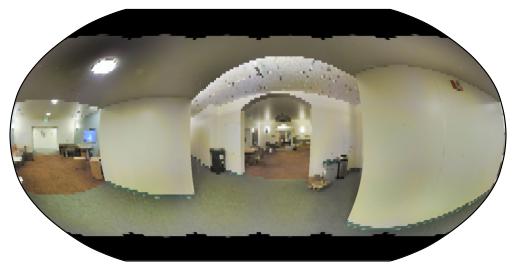

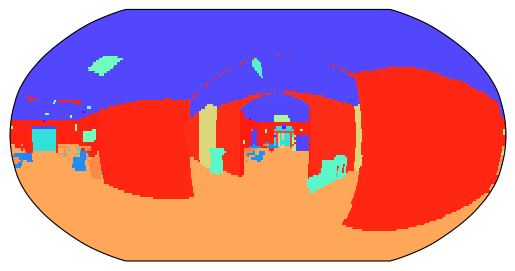

In [4]:
h5file = h5.File(os.path.join(data_dir, "segmentation_dataset.h5"), "r")

print(h5file.keys())

inp = np.transpose(h5file["inputs"][0, ...], (1,2,0))
tar = h5file["targets"][0, ...]
classes = h5file["class_labels"]
num_classes = len(classes)

imshow_sphere(inp)
plot_data(tar / num_classes, cmap="rainbow", central_longitude=0, vmin=0.0, vmax=1.0)

In [4]:
dataset = SphericalSegmentationDataset(dataset_file=dataset_file)

inp, tar = dataset[0]

In [ ]:
inp.shape

In [ ]:
imshow_sphere(inp.permute(1, 2, 0).numpy())

plot_data(tar.numpy() / num_classes, cmap="rainbow", central_longitude=0, vmin=0.0, vmax=1.0)